# Facial Expression Classification with CNN
## Step 1: Understanding the Data

Before building any model, we explore the dataset to understand its structure,
class distribution, and potential challenges.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# Path to the FER-2013 folder
TRAIN_DIR = "C:/Users/elzah/Deep_Learning/FER-2013/train"
TEST_DIR = "C:/Users/elzah/Deep_Learning/FER-2013/test"

# Get class names
classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)

# Count images per class
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}
test_counts  = {cls: len(os.listdir(os.path.join(TEST_DIR, cls)))  for cls in classes}

print("\nTraining images per class:")
for cls, count in train_counts.items():
    print(f"  {cls}: {count}")

print("\nTest images per class:")
for cls, count in test_counts.items():
    print(f"  {cls}: {count}")

print(f"\nTotal training images: {sum(train_counts.values())}")
print(f"Total test images:     {sum(test_counts.values())}")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Training images per class:
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171

Test images per class:
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831

Total training images: 28709
Total test images:     7178


The dataset contains 7 emotion classes. One immediate concern is class imbalance:
`disgust` has only 436 training images compared to `happy` with 7,215 — a 16x difference.
This may cause the model to perform poorly on underrepresented classes.

### Class Distribution

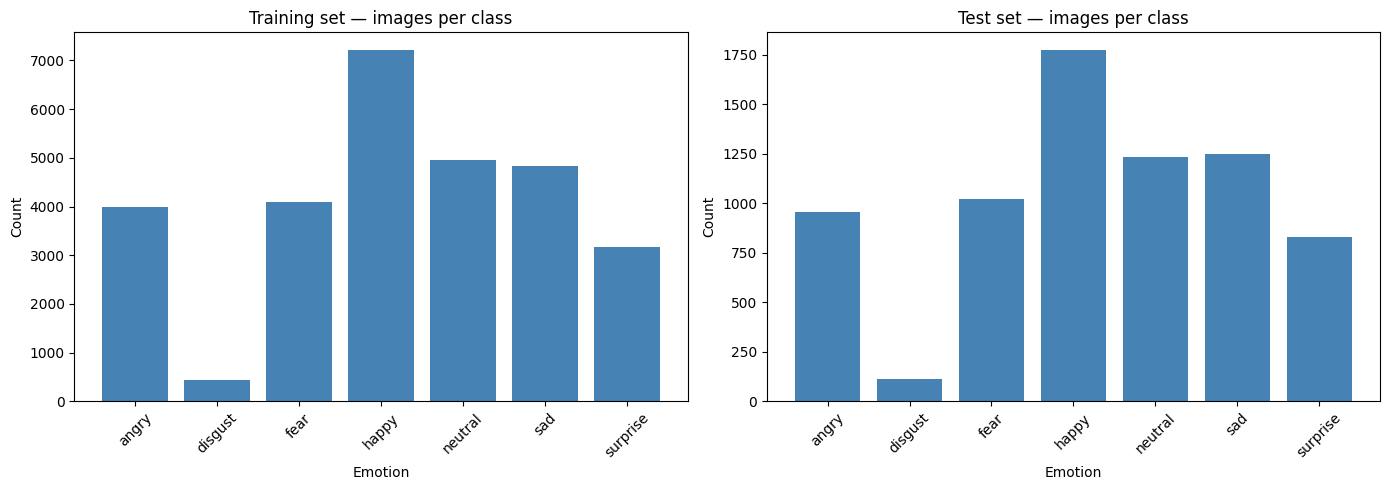

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(axes, [train_counts, test_counts], ["Training", "Test"]):
    ax.bar(counts.keys(), counts.values(), color="steelblue")
    ax.set_title(f"{title} set — images per class")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Observations

The dataset contains 7 emotion classes with a total of 28,709 training and 7,178 test images.

**Class imbalance is significant:**
- `happy` dominates with 7,215 training images
- `disgust` has only 436 — roughly 16x fewer than `happy`

This imbalance can cause the model to become biased toward majority classes and perform poorly on underrepresented ones like `disgust`. This is something to keep in mind when interpreting accuracy later.

The train/test split is approximately 80/20, which is standard practice.

### Sample Images per Class

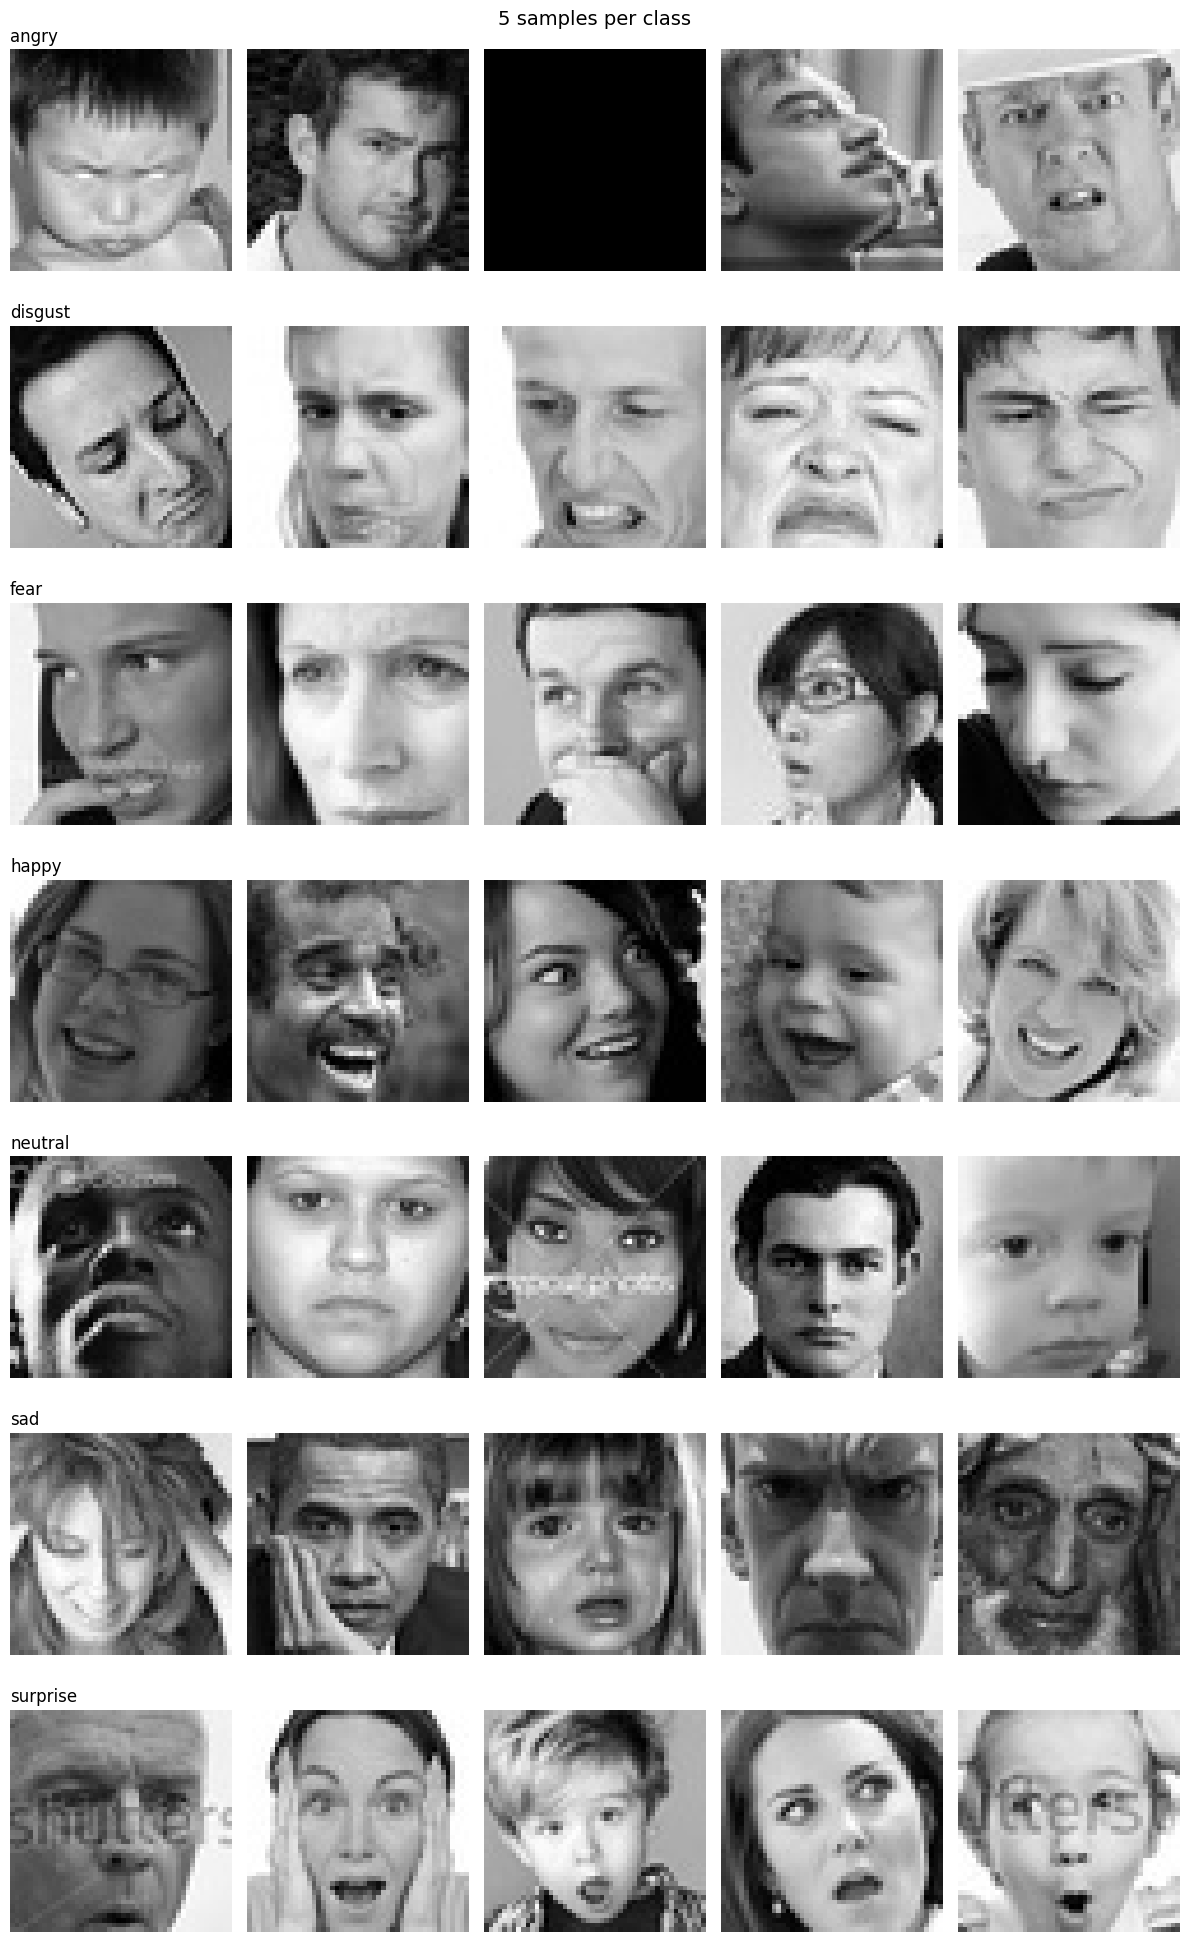

In [3]:
fig, axes = plt.subplots(len(classes), 5, figsize=(12, 20))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_dir)[:5]
    for j, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(cls_dir, img_name))
        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(cls, fontsize=12, loc="left")

plt.suptitle("5 samples per class", fontsize=14)
plt.tight_layout()
plt.show()

### Observations

The images are 48x48 pixel grayscale photos of faces, each labeled with one of 7 emotions.
Some observations:
- Image quality and lighting vary considerably across samples
- Some images are ambiguous — even for a human, distinguishing e.g. `fear` from `surprise` 
  is not always obvious
- `disgust` samples look visually similar to `angry`, which may cause the model to confuse 
  these classes
- Some images appear to have watermarks (visible in `surprise` samples)
- At least one completely black image is visible in the `angry` class — an example of 
  corrupted or mislabeled data in the dataset. This kind of noise is common in real-world 
  datasets and can negatively affect model training.

These factors will likely affect model performance.

## Step 2: Preparing the Data

The images need to be loaded and normalized before they can be used for training.
We use TensorFlow's `image_dataset_from_directory` which automatically reads the 
folder structure and assigns labels based on subfolder names.

An 80/20 validation split is created from the training data. The test set is kept 
separate and only used for final evaluation.

In [ ]:
IMG_SIZE = 48
BATCH_SIZE = 32

# Create train/validation split directly from training folder
train_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

# Test dataset
test_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

print("Class names:", train_raw.class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = (
    train_raw
    .map(lambda x, y: (normalization_layer(x), y))
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_raw
    .map(lambda x, y: (normalization_layer(x), y))
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_raw
    .map(lambda x, y: (normalization_layer(x), y))
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets normalized and ready.")

Datasets normalized and ready.


In [36]:
# Smaller subsets for quick experimentation
small_train_ds = train_ds.take(100)
small_val_ds = val_ds.take(20)
small_test_ds = test_ds.take(30)

print("Small subsets created for faster experimentation.")

# Note: evaluation is done on the full test_ds for more reliable metrics

Small subsets created for faster experimentation.


### Data Preparation Notes

- The training data was split into training and validation sets using an 80/20 split.
- Images were normalized from [0, 255] to [0, 1] to improve training stability.
- Prefetching was used to improve pipeline performance during training.
- Smaller subsets of the dataset were initially used for faster experimentation and debugging before scaling up to the full dataset.
- Using smaller subsets may slightly alter the original class distribution, which can affect model performance.

## Step 3: Building the Model

We build a CNN (Convolutional Neural Network) — the standard architecture for image classification.
We start with a simple baseline model, then improve it in later steps.

In [ ]:
def build_model():
    model = models.Sequential([
        # Input
        layers.Input(shape=(48, 48, 1)),
        
        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        
        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(7, activation="softmax")
    ])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,375 (4.86 MB)

 Trainable params: 1,274,375 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

### Model Architecture

A sequential CNN with 3 convolutional blocks followed by a dense classifier:

- **Conv2D + MaxPooling blocks**: extract increasingly complex features from the images. 
  Filters go 32 → 64 → 128, meaning the network learns more complex patterns in deeper layers
- **Flatten**: converts the 2D feature maps to a 1D vector
- **Dense(256)**: learns combinations of the extracted features
- **Dropout(0.5)**: randomly disables 50% of neurons during training to reduce overfitting
- **Dense(7, softmax)**: outputs a probability for each of the 7 emotion classes

Total trainable parameters: ~1.27 million — reasonable for this task.

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled.")

Model compiled.


## Step 4: Training the Model
### Iteration 1: Initial Training on Small Subset

We start with ~3,200 images (100 batches) and 10 epochs to verify the pipeline works
before committing to longer training runs.

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    small_train_ds,
    validation_data=small_val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.2556 - loss: 1.8328 - val_accuracy: 0.2453 - val_loss: 1.8150
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2706 - loss: 1.7995 - val_accuracy: 0.2734 - val_loss: 1.8030
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2937 - loss: 1.7422 - val_accuracy: 0.3031 - val_loss: 1.7365
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3303 - loss: 1.6761 - val_accuracy: 0.3438 - val_loss: 1.6854
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3597 - loss: 1.6138 - val_accuracy: 0.3859 - val_loss: 1.6292
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4081 - loss: 1.5334 - val_accuracy: 0.3906 - val_loss: 1.6374
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4456 - loss: 1.4620 - val_accuracy: 0.3953 - val_loss: 1.5975
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4766 - loss: 1.3904 - val_accu

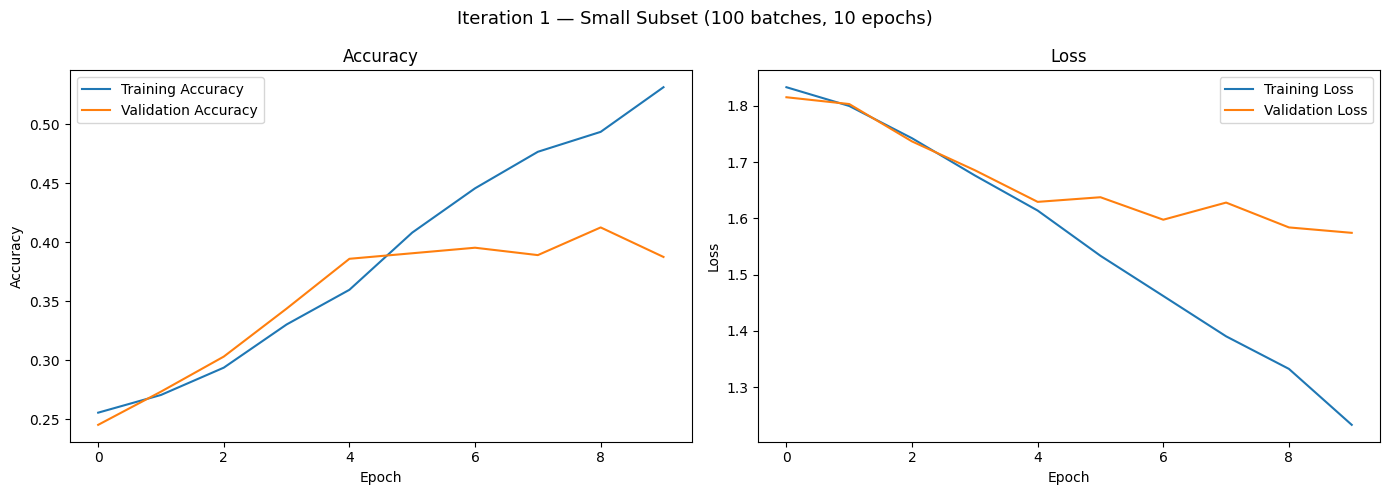

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Iteration 1 — Small Subset (100 batches, 10 epochs)", fontsize=13)

axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

### Iteration 1: Observations

**Accuracy:** Training accuracy reaches ~52% while validation accuracy plateaus around 
39–41% and becomes noisy in later epochs. The growing gap between the two curves 
confirms overfitting.

**Loss:** Both training and validation loss decrease steadily in the first 4 epochs, 
moving together — a good sign. After epoch 4, training loss continues to drop sharply 
while validation loss flattens around 1.58–1.63. This divergence is an early sign of 
overfitting: the model is memorizing the small training set rather than generalizing.

**Conclusion:** The model is learning but the small dataset (3,200 images) limits 
generalization. More data and regularization are needed. In Iteration 2 we scale up 
to ~16,000 training images and increase to 20 epochs.

### Iteration 2: Larger Subset

The initial run with ~3,200 images showed the model is learning (accuracy improving each epoch)
but the dataset is too small to achieve good performance. We now scale up to ~16,000 training 
images and increase to 20 epochs to give the model more to learn from.

In [12]:
# Rebuild and recompile model to start fresh
model2 = build_model()
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Use larger subset: 500 batches × 32 = ~16,000 training images
large_train_ds = train_ds.take(500)
large_val_ds = val_ds.take(100)

early_stopping2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history2 = model2.fit(
    large_train_ds,
    validation_data=large_val_ds,
    epochs=20,
    callbacks=[early_stopping2]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.2777 - loss: 1.7629 - val_accuracy: 0.3638 - val_loss: 1.6191
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.4008 - loss: 1.5453 - val_accuracy: 0.4572 - val_loss: 1.4366
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4613 - loss: 1.4065 - val_accuracy: 0.4834 - val_loss: 1.3658
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4952 - loss: 1.3028 - val_accuracy: 0.4866 - val_loss: 1.3365
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5334 - loss: 1.2291 - val_accuracy: 0.5041 - val_loss: 1.3202
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5656 - loss: 1.1512 - val_accuracy: 0.5141 - val_loss: 1.2777
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5897 - loss: 1.0828 - val_accuracy: 0.5250 - val_loss: 1.2956
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6202 - loss: 1.0042 - val_acc

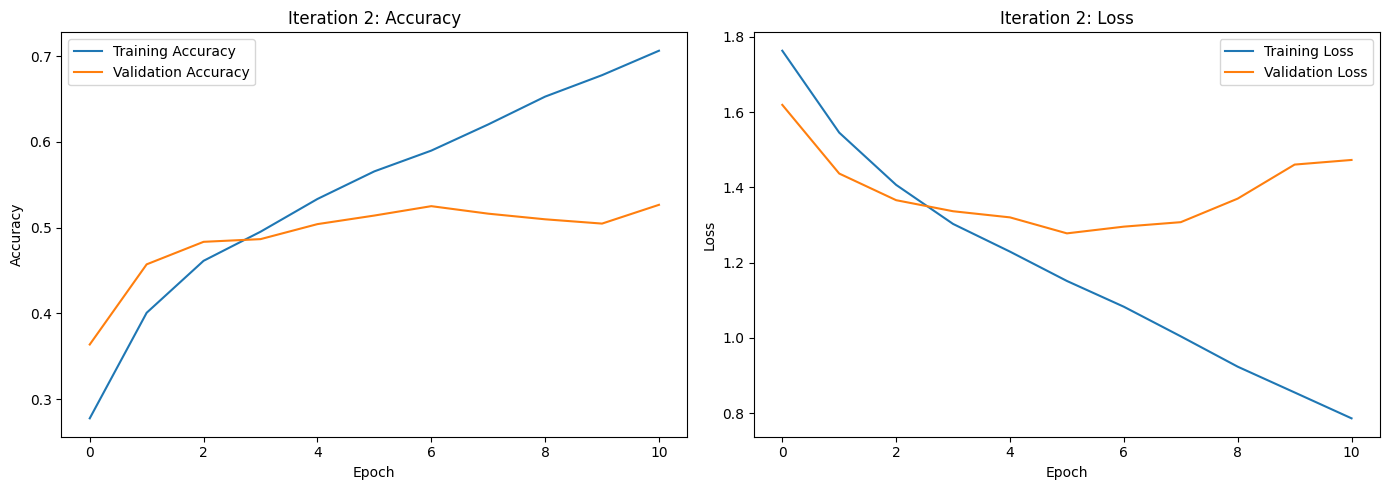

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history2.history["accuracy"], label="Training Accuracy")
axes[0].plot(history2.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Iteration 2: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history2.history["loss"], label="Training Loss")
axes[1].plot(history2.history["val_loss"], label="Validation Loss")
axes[1].set_title("Iteration 2: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

### Iteration 2: Observations

Scaling up to ~16,000 images improved results considerably compared to Iteration 1.
Validation accuracy reached ~52% (up from ~39%), and early stopping correctly halted 
training at epoch 11, restoring the best weights from epoch 6.

However, the large and growing gap between training accuracy (~70%) and validation 
accuracy (~52%) indicates significant overfitting — the model is memorizing the 
training data rather than generalizing.

### Iteration 3: Reducing Overfitting

To address overfitting we introduce three changes simultaneously for practical reasons 
(CPU training time). In a real-world setting, each change would ideally be tested 
independently to isolate its effect.
- **Batch Normalization** after each conv block — stabilizes training
- **Dropout after conv blocks** (0.25) — regularizes earlier in the network
- **Data Augmentation** (horizontal flip + slight rotation) — increases effective dataset variety, applied to training data only

In [15]:
def build_model_v3():
    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),

        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(7, activation="softmax")
    ])
    return model

# Augmentation applied separately to training data only
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

augmented_train_ds = large_train_ds.map(
    lambda x, y: (augment(x, training=True), y)
).prefetch(tf.data.AUTOTUNE)

model3 = build_model_v3()
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping3 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history3 = model3.fit(
    augmented_train_ds,
    validation_data=large_val_ds,
    epochs=20,
    callbacks=[early_stopping3]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.2309 - loss: 1.9364 - val_accuracy: 0.2491 - val_loss: 2.2145
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.2592 - loss: 1.8015 - val_accuracy: 0.3088 - val_loss: 1.7038
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.2711 - loss: 1.7532 - val_accuracy: 0.3022 - val_loss: 1.6974
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.2812 - loss: 1.7247 - val_accuracy: 0.3225 - val_loss: 1.6095
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.3030 - loss: 1.6932 - val_accuracy: 0.3747 - val_loss: 1.5529
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3134 - loss: 1.6625 - val_accuracy: 0.3969 - val_loss: 1.5192
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3283 - loss: 1.6395 - val_accuracy: 0.4150 - val_loss: 1.5092
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.3461 - loss: 1.6175 - 

### Iteration 3: Observations

The model ran all 20 epochs without early stopping triggering, suggesting it is still 
learning. Compared to Iteration 2:

- The train/val accuracy gap narrowed significantly (~6% vs ~18%) — overfitting is reduced
- Validation accuracy reached ~50%, similar to Iteration 2 but with better generalization
- Training is slower due to augmentation and lower learning rate — the model needs more epochs

We continue training for 20 more epochs to allow the model to converge further.

In [16]:
history3b = model3.fit(
    augmented_train_ds,
    validation_data=large_val_ds,
    epochs=20,
    callbacks=[early_stopping3]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.4499 - loss: 1.4278 - val_accuracy: 0.4963 - val_loss: 1.3212
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.4485 - loss: 1.4246 - val_accuracy: 0.4828 - val_loss: 1.3670
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4526 - loss: 1.4157 - val_accuracy: 0.4837 - val_loss: 1.3691
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.4591 - loss: 1.4076 - val_accuracy: 0.5103 - val_loss: 1.2924
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.4656 - loss: 1.3960 - val_accuracy: 0.5222 - val_loss: 1.2521
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.4675 - loss: 1.3890 - val_accuracy: 0.5119 - val_loss: 1.3049
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.4673 - loss: 1.3905 - val_accuracy: 0.5147 - val_loss: 1.2876
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.4701 - loss: 1.3769 - 

### Iteration 3b: Observations

Early stopping triggered at epoch 10, restoring best weights from epoch 5 
(val_loss: 1.2521, val_accuracy: ~53%).

The model has plateaued — further training with this architecture and dataset 
size is unlikely to improve results significantly. Iteration 3 gives the best 
balance between training and validation accuracy with only a ~6% gap, 
indicating good generalization compared to earlier iterations.

We save this as our final model and proceed to evaluation.

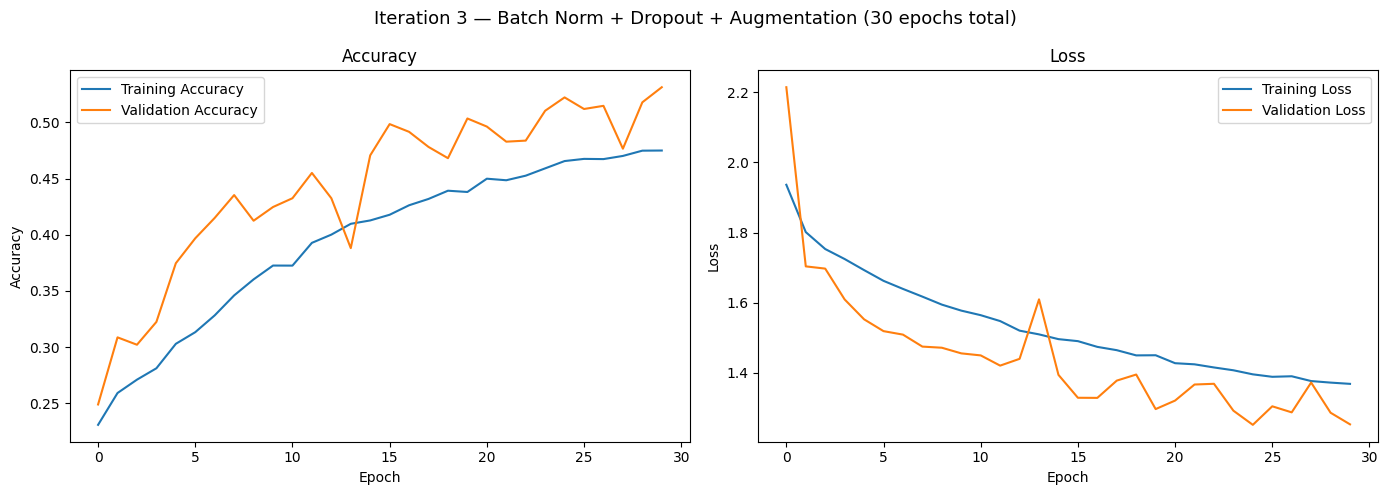

In [21]:
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

combined3 = combine_histories(history3, history3b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Iteration 3 — Batch Norm + Dropout + Augmentation (30 epochs total)", fontsize=13)

axes[0].plot(combined3["accuracy"], label="Training Accuracy")
axes[0].plot(combined3["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(combined3["loss"], label="Training Loss")
axes[1].plot(combined3["val_loss"], label="Validation Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

### Iteration 3: Training Curves Analysis

Notably, validation accuracy consistently exceeds training accuracy — the opposite 
of typical overfitting. This is caused by data augmentation: random flips and 
rotations make training harder, so the model appears weaker on training data 
than on clean validation data.

The spike at epoch 13 marks where training resumed in the second run (history3b).
Both loss curves converge without diverging, confirming the regularization is working.
This is our best model — lowest overfitting and highest validation accuracy (~53%).

In [ ]:
os.makedirs("model", exist_ok=True)
model3.save("model/facial_expression_model.keras")
print("Model saved.")

Model saved.


In [ ]:
os.makedirs("model", exist_ok=True)
model3.save("model/facial_expression_model.keras")

# Save training histories so plots can be regenerated without retraining
with open("model/history3.json", "w") as f:
    json.dump(history3.history, f)
with open("model/history3b.json", "w") as f:
    json.dump(history3b.history, f)

print("Model and histories saved.")

# To reload histories if re-running notebook without retraining:
# with open("model/history3.json") as f:
#     history3_data = json.load(f)
# with open("model/history3b.json") as f:
#     history3b_data = json.load(f)
# combined3 = {key: history3_data[key] + history3b_data[key] for key in history3_data}

In [32]:
# Verify the model can be loaded
loaded_model = tf.keras.models.load_model("model/facial_expression_model.keras")
print("Model loaded successfully.")

Model loaded successfully.


### Summary: Iteration Comparison

In [ ]:
comparison = pd.DataFrame({
    "Iteration": ["Iteration 1", "Iteration 2", "Iteration 3"],
    "Train Accuracy": ["~52%", "~70%", "~47%"],
    "Val Accuracy":   ["~39%", "~52%", "~53%"],
    "Gap":            ["13%",  "18%",  "6%"],
    "Notes": [
        "Small subset, clear overfitting",
        "Larger subset, overfitting worsens",
        "BatchNorm + Dropout + Augmentation, best generalization"
    ]
})

pd.set_option("display.max_colwidth", None)
comparison

,Iteration,Train Accuracy,Val Accuracy,Gap,Notes
0,Iteration 1,~52%,~39%,13%,"Small subset, clear overfitting"
1,Iteration 2,~70%,~52%,18%,"Larger subset, overfitting worsens"
2,Iteration 3,~47%,~53%,6%,"BatchNorm + Dropout + Augmentation, best generalization"


## Step 5: Evaluating the Model

We evaluate the final model (Iteration 3) on the test set to see how well it 
generalizes to completely unseen data.

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = model3.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5280 - loss: 1.2584

Test Accuracy: 0.5280
Test Loss:     1.2584


              precision    recall  f1-score   support

       angry       0.39      0.45      0.42       958
     disgust       0.00      0.00      0.00       111
        fear       0.31      0.16      0.21      1024
       happy       0.73      0.82      0.77      1774
     neutral       0.50      0.47      0.48      1233
         sad       0.39      0.48      0.43      1247
    surprise       0.66      0.68      0.67       831

    accuracy                           0.53      7178
   macro avg       0.42      0.44      0.43      7178
weighted avg       0.51      0.53      0.51      7178



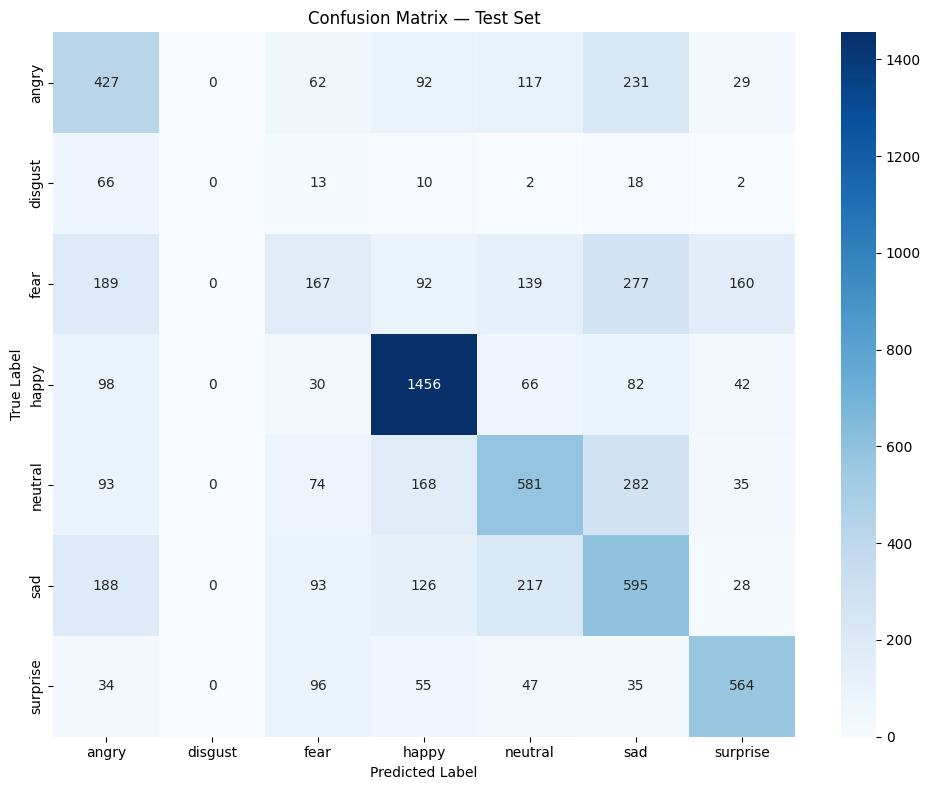

In [27]:
# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model3.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = train_raw.class_names

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

### Evaluation Observations

**Overall test accuracy: 52.8%** — consistent with validation accuracy, confirming 
the model generalizes well without overfitting to the validation set. Beyond accuracy, 
we use precision, recall and F1-score per class to get a fuller picture, since 
accuracy alone is misleading on imbalanced datasets.

**Per-class performance varies significantly:**

- `happy` performs best (F1: 0.77) — it has the most training data (7,215 images) 
  and is visually distinct
- `surprise` also performs well (F1: 0.67) — likely due to distinct visual features 
  (raised eyebrows, open mouth)
- `disgust` scores F1: 0.00 — the model never predicts it. This is a direct consequence 
  of class imbalance: only 436 training images, the model learned to ignore it entirely
- `fear` performs poorly (F1: 0.21) — heavily confused with `sad` and `neutral`, 
  which are visually similar

**Confusion matrix highlights:**
- `fear` is most often misclassified as `sad` (277 times) — these emotions share 
  similar facial features
- `neutral` and `sad` are frequently confused with each other
- `disgust` is always predicted as `angry` — visually the most similar class

**Key limitation:** class imbalance is the single biggest factor affecting performance. 
A model trained on balanced data would likely perform significantly better on minority classes.

### Addressing the Disgust Problem

The model never predicts `disgust` because it learned that ignoring it minimizes 
overall loss — with only 436 training samples out of 28,709, predicting `angry` 
instead costs very little in terms of accuracy.

**This is fixable.** The main approaches are:

- **Class weights**: tell the model to penalize mistakes on minority classes more 
  heavily during training. Simple to implement in Keras with `class_weight` parameter in `model.fit()`
- **Oversampling**: duplicate or augment `disgust` images specifically to balance the dataset
- **Undersampling**: reduce majority classes to match minority class size (loses data)

For this project, we acknowledge it as a known limitation. In a production setting, 
class weights would be the first thing to try — it requires only a few lines of code 
and no changes to the model architecture.

## Step 6: Predictions on New Data

We use the final model to predict the emotion of images it has never seen during training.
We test on images from the test set — these were not used during training or validation.


True label: angry


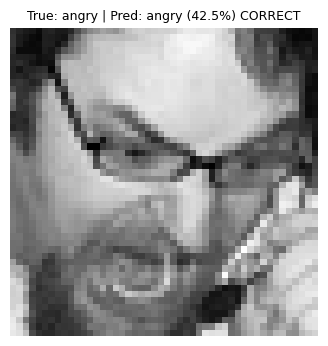

Class probabilities:
  angry     : 42.5%
  disgust   : 3.6%
  fear      : 14.3%
  happy     : 14.1%
  neutral   : 7.1%
  sad       : 17.8%
  surprise  : 0.6%

True label: disgust


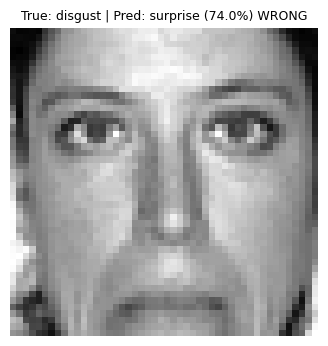

Class probabilities:
  angry     : 1.7%
  disgust   : 0.0%
  fear      : 21.5%
  happy     : 1.4%
  neutral   : 0.4%
  sad       : 1.0%
  surprise  : 74.0%

True label: fear


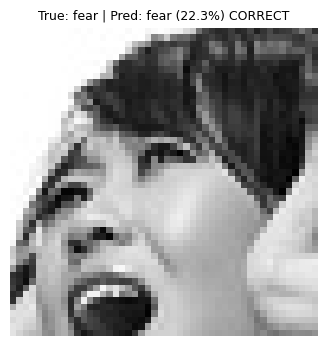

Class probabilities:
  angry     : 19.5%
  disgust   : 1.7%
  fear      : 22.3%
  happy     : 10.6%
  neutral   : 17.5%
  sad       : 18.3%
  surprise  : 10.1%

True label: happy


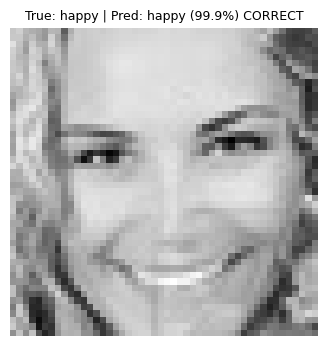

Class probabilities:
  angry     : 0.0%
  disgust   : 0.0%
  fear      : 0.0%
  happy     : 99.9%
  neutral   : 0.1%
  sad       : 0.0%
  surprise  : 0.0%

True label: neutral


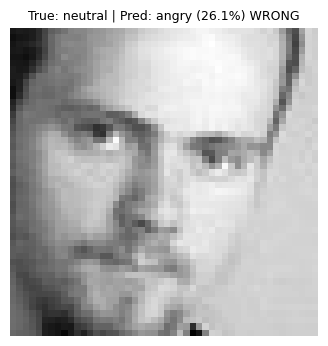

Class probabilities:
  angry     : 26.1%
  disgust   : 4.3%
  fear      : 21.7%
  happy     : 2.5%
  neutral   : 19.2%
  sad       : 25.3%
  surprise  : 0.8%

True label: sad


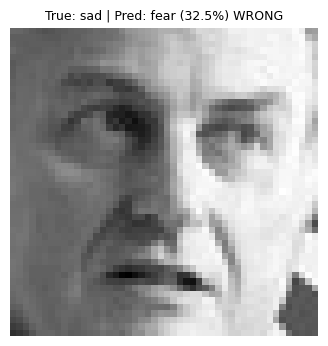

Class probabilities:
  angry     : 17.9%
  disgust   : 5.1%
  fear      : 32.5%
  happy     : 14.7%
  neutral   : 6.9%
  sad       : 17.1%
  surprise  : 5.9%

True label: surprise


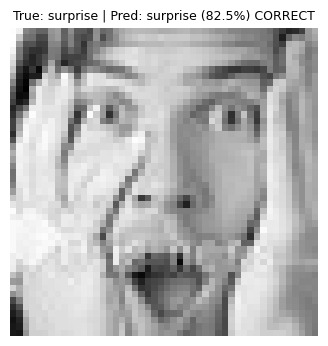

Class probabilities:
  angry     : 1.0%
  disgust   : 0.0%
  fear      : 15.9%
  happy     : 0.5%
  neutral   : 0.1%
  sad       : 0.1%
  surprise  : 82.5%


In [ ]:
def predict_image(img_path, model, class_names, true_label=None):
    img = Image.open(img_path).convert("L")
    img = img.resize((48, 48))
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 48, 48, 1)
    
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100
    
    correct = "CORRECT" if predicted_class == true_label else "WRONG"
    title = f"True: {true_label} | Pred: {predicted_class} ({confidence:.1f}%) {correct}"
    
    plt.figure(figsize=(4, 4))
    plt.imshow(np.array(img), cmap="gray")
    plt.title(title, fontsize=9)
    plt.axis("off")
    plt.show()
    
    print("Class probabilities:")
    for name, prob in zip(class_names, predictions[0]):
        print(f"  {name:10s}: {prob*100:.1f}%")

test_images = []
for cls in class_names:
    cls_dir = os.path.join(TEST_DIR, cls)
    first_img = os.listdir(cls_dir)[0]
    test_images.append((os.path.join(cls_dir, first_img), cls))

for img_path, true_label in test_images:
    print(f"\nTrue label: {true_label}")
    predict_image(img_path, model3, class_names, true_label=true_label)

### Step 6: Prediction Observations

Testing one image per class gives 4/7 correct predictions, consistent with the 
overall test accuracy of 52.8%.

**Notable results:**
- `happy` predicted with 99.9% confidence — the model is very certain on clear, 
  visually distinct expressions
- `surprise` predicted correctly at 82.5% — also visually distinctive
- `fear` predicted correctly but with only 22.3% confidence — probabilities spread 
  across multiple classes, showing the model is uncertain
- `disgust` misclassified as `surprise` — confirms the model has not learned this class
- `neutral` misclassified as `angry` with only 26.1% confidence — the model is 
  uncertain and the probabilities are spread almost evenly across several classes

The confidence scores are informative: high confidence tends to correlate with 
correct predictions on visually distinct emotions.

## Step 7: Analysing the Results

### How well does the model perform?

The final model (Iteration 3) achieved **52.8% test accuracy** on 7 emotion classes.
Random guessing on 7 classes would give ~14.3%, so the model is clearly learning 
meaningful patterns. However, human-level performance on FER-2013 is estimated at 
around 65%, so there is room for improvement.

### Overfitting or underfitting?

Iteration 2 showed clear overfitting — training accuracy reached 70% while validation 
stayed at 52%, a gap of 18 percentage points. Iteration 3 addressed this with batch 
normalization, dropout, and data augmentation, reducing the gap to ~6%. The model 
is not underfitting either — loss decreases steadily and accuracy improves over epochs.

### Difference between training and test results?

Validation accuracy (~53%) and test accuracy (52.8%) are nearly identical, which is 
a good sign — the model generalizes consistently and was not accidentally tuned 
toward the validation set.

### What affects the result most?

Three factors stand out:
- **Class imbalance** — `disgust` is never predicted correctly due to having 16x fewer 
  images than `happy`. This is the single biggest limitation.
- **Visual similarity between classes** — `fear`, `sad`, and `neutral` share similar 
  facial features and are frequently confused with each other.
- **Dataset size used for training** — we used ~16,000 of 28,709 available training 
  images. Training on the full dataset would likely improve performance.

### Model limitations

- Cannot reliably distinguish visually similar emotions (fear/sad/neutral)
- Completely fails on `disgust` due to class imbalance
- Trained on grayscale 48x48 images — low resolution limits the features available
- Performance may degrade on images that differ from the FER-2013 distribution 
  (different lighting, pose, age, ethnicity)
- No real-time capability in current form

## Step 8: Reflection

### What was hardest?

The biggest technical challenge was getting the training pipeline to work at all. 
In the beginning, multiple attempts failed or ran indefinitely — the first try used 
`.cache()` on the full dataset which caused training to hang for 10 hours without 
completing a single epoch. Even after fixing that, choosing too large a subset for 
initial testing meant epochs took 20+ minutes each, making it impossible to iterate 
quickly. Learning to deliberately downscale — start with 100 batches, verify the 
pipeline works, then scale up — was not intuitive at first but turned out to be the 
key to making progress.

A different kind of challenge was accepting the model's limitations and moving forward 
without trying to fix everything. Seeing wrong predictions and a 53% accuracy felt 
unsatisfying — the instinct was to keep tweaking. Learning to document and analyse 
a flawed model honestly, rather than chase a perfect one, turned out to be an 
important part of the process.

Conceptually, understanding the tradeoff between overfitting and underfitting — and 
how to address it iteratively — was the most valuable learning experience.

### What did I learn?

- How to build, train and evaluate a CNN from scratch
- That data quality and balance matter as much as model architecture
- How to read and interpret training curves to diagnose overfitting
- That iterative development (test small, scale up) is essential in practice
- The practical limitations of training on CPU and how to work around them

### What would I do differently?

- Start with class weights from the beginning to address the `disgust` imbalance
- Use a smaller but balanced subset rather than a large imbalanced one
- Consider transfer learning (e.g. a pretrained MobileNet) which would likely 
  outperform a CNN trained from scratch on this dataset size
- Train on GPU (Google Colab) to allow faster iteration and more epochs

### Grade assessment

I believe this submission corresponds to **VG** based on the following:

- Built a working CNN and trained it correctly
- Iterated through 3 model versions with documented reasoning for each change
- Compared results across iterations with training curve analysis
- Identified and explained overfitting, addressed it with concrete techniques
- Conducted a deep analysis including confusion matrix, per-class metrics, 
  and class imbalance discussion
- Discussed model limitations and how they could be addressed
- Made predictions on unseen data with confidence score analysis